In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import arviz as az
import colorsys

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2" # second gpu
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140

from matplotlib import rc

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [17]:
import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [18]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

def scale_to_bounds(x, axis=0, eps=1e-3):
    """
    Linearly rescales x along `axis` so that
      min → eps, max → 1-eps,
    and everything else is in between.
    """
    # compute min and max (keepdims so we can broadcast)
    mn = x.min(axis=axis, keepdims=True)
    mx = x.max(axis=axis, keepdims=True)
    # normalize to [0,1]
    x0 = (x - mn) / (mx - mn)
    # stretch to [eps, 1-eps]
    return x0 * (1 - 2*eps) + eps

In [19]:
# Data Prepping

# copy r_table completely to keep backup
rdf = r_table.copy()

# Add 2 more columns,
# - target at previous trial
# - response at previous trial

rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)

# Replace NaN values in the first trial of each group with the current trial's value
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])


In [20]:
# Fundamental input parameters
baseline_bias = np.ones((288, 120, 1))

coherence = (rdf.coh == "high").astype(np.float32).values.reshape(-1, 120, 1)
attention = (rdf.att == "focused").astype(np.float32).values.reshape(-1, 120, 1)
expectation = (rdf.exp_al == "expected").astype(np.float32).values.reshape(-1, 120, 1)

resp_err = np.deg2rad(rdf.resp_err.values.reshape(-1, 120, 1))
surprise = np.deg2rad((rdf.t_calib - rdf.exp).values.reshape(-1, 120, 1))
surprise = np.nan_to_num(surprise, nan=0.0)

stim = np.deg2rad(rdf.t_calib.values.reshape(-1, 120, 1))
prev_stim = np.deg2rad(rdf.prev_target.values.reshape(-1, 120, 1))
prev_resp = np.deg2rad(rdf.prev_resp.values.reshape(-1, 120, 1))

# Emissions
# min max scale it using first axis - we are scaling each trial independently
# Reaction time: subtract baseline and convert to ms/frame
rt_raw = (r_table.f_resp.values - 250).reshape(-1, 120, 1) * (1000/120)
# reaction_time = scale_to_bounds(rt_raw, axis=0, eps=1e-3)
# just make it so that its above 0
reaction_time = np.clip(rt_raw, 0.01, None)

# Response angle stays as radians (no scaling necessary)
response_angle = np.deg2rad(r_table.resp.values).reshape(-1, 120, 1)

# Response error: convert to radians then rescale into (eps,1-eps)
err_raw = np.deg2rad(r_table.resp_err.values).reshape(-1, 120, 1)
response_error = scale_to_bounds(err_raw, axis=0, eps=1e-3)

In [21]:

# print and check if any of these have nan in them
print("coherence", np.isnan(coherence).sum())
print("attention", np.isnan(attention).sum())
print("expectation", np.isnan(expectation).sum())

print("surprise", np.isnan(surprise).sum())
print("resp_err", np.isnan(resp_err).sum())

print("stim", np.isnan(stim).sum())
print("prev_stim", np.isnan(prev_stim).sum())
print("prev_resp", np.isnan(prev_resp).sum())

print("reaction_time", np.isnan(reaction_time).sum())
print("response_angle", np.isnan(response_angle).sum())
print("response_error", np.isnan(response_error).sum())

coherence 0
attention 0
expectation 0
surprise 0
resp_err 0
stim 0
prev_stim 0
prev_resp 0
reaction_time 0
response_angle 0
response_error 0


## GLM RT

In [22]:
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [23]:
# -- 1. Load your DataFrame (df) here --

df = pd.DataFrame(
    {
        "Error": response_error.flatten(),
        "Surprise": surprise.flatten(),
        "Attention": attention.flatten(),
        "Coh": coherence.flatten(),
        "Exp": expectation.flatten(),
        "rt": reaction_time.flatten(),
    }
)

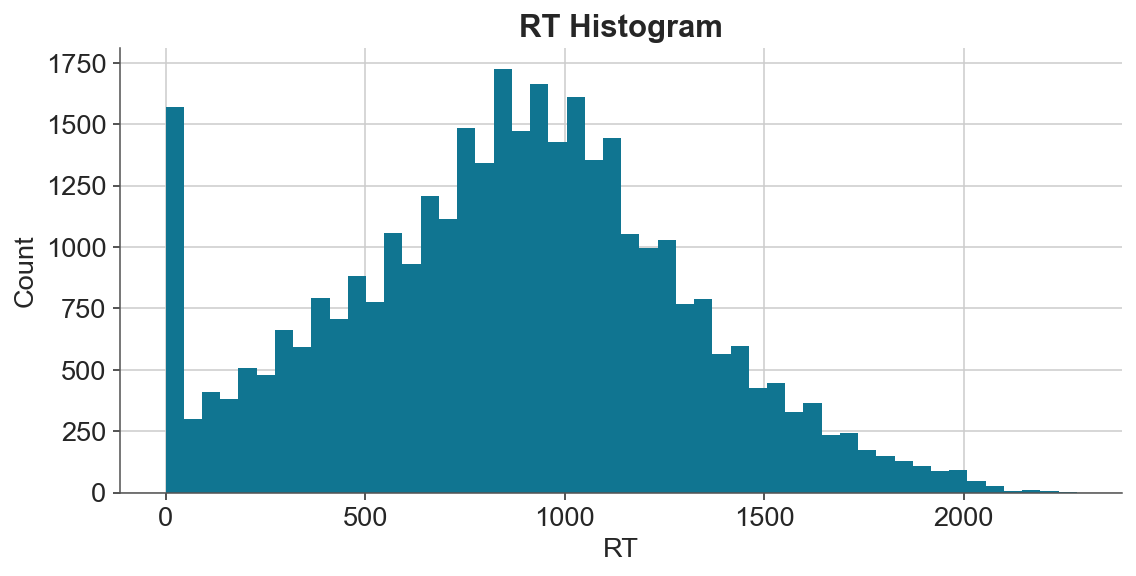

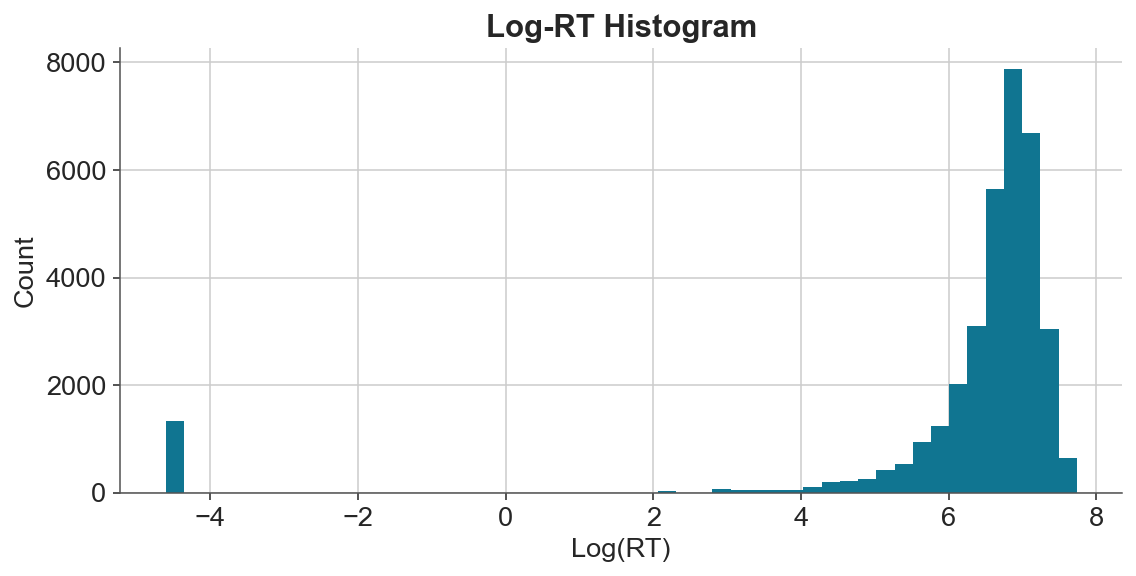

Mean: 863.2903136574075
Variance: 189251.28902248986
Skewness: 0.005435839202099275
Kurtosis: -0.293215621740341


In [24]:
# Identify response and predictors
y_col = df.columns[-1]
X_cols = df.columns[:-1]
continuous_cols = ['Error', 'Surprise']  # adjust if your continuous IVs have different names
flag_cols = ['Attention', 'Coh', 'Exp']  # your binary manipulation flags

# -- 2. Exploratory Data Analysis --
plt.figure(figsize=(8, 4))
df[y_col].hist(bins=50)
plt.title('RT Histogram')
plt.xlabel('RT')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 4))
np.log(df[y_col]).hist(bins=50)
plt.title('Log-RT Histogram')
plt.xlabel('Log(RT)')
plt.ylabel('Count')
plt.show()

print("Mean:", df[y_col].mean())
print("Variance:", df[y_col].var())
print("Skewness:", df[y_col].skew())
print("Kurtosis:", df[y_col].kurtosis())


In [25]:

# -- 3. Test Noise Distribution --
rt = df[y_col].values

# Fit Gamma (with loc=0) and Lognormal
a_g, loc_g, scale_g = stats.gamma.fit(rt, floc=0)
s_ln, loc_ln, scale_ln = stats.lognorm.fit(rt, floc=0)

# KS tests
ks_g = stats.kstest(rt, 'gamma', args=(a_g, loc_g, scale_g))
ks_ln = stats.kstest(rt, 'lognorm', args=(s_ln, loc_ln, scale_ln))
print("KS Gamma:", ks_g)
print("KS Lognormal:", ks_ln)

# AIC comparison
k = 2  # #params for simple distribution fits
ll_g = stats.gamma.logpdf(rt, a_g, loc_g, scale_g).sum()
ll_ln = stats.lognorm.logpdf(rt, s_ln, loc_ln, scale_ln).sum()
AIC_g = 2*k - 2*ll_g
AIC_ln = 2*k - 2*ll_ln
print("AIC Gamma:", AIC_g, "AIC Lognormal:", AIC_ln)


KS Gamma: KstestResult(statistic=0.2313552798550043, pvalue=0.0, statistic_location=566.6666666666667, statistic_sign=-1)
KS Lognormal: KstestResult(statistic=0.3043116344354065, pvalue=0.0, statistic_location=375.0, statistic_sign=-1)
AIC Gamma: 536382.1640429201 AIC Lognormal: 583722.4362318317


/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                     rt   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34557
Model Family:                   Gamma   Df Model:                            2
Link Function:                    log   Scale:                         0.25956
Method:                          IRLS   Log-Likelihood:            -2.9660e+05
Date:                Mon, 12 May 2025   Deviance:                       37750.
Time:                        12:42:19   Pearson chi2:                 8.97e+03
No. Iterations:                    11   Pseudo R-squ. (CS):            0.01961
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.8299      0.004   1755.670      0.0

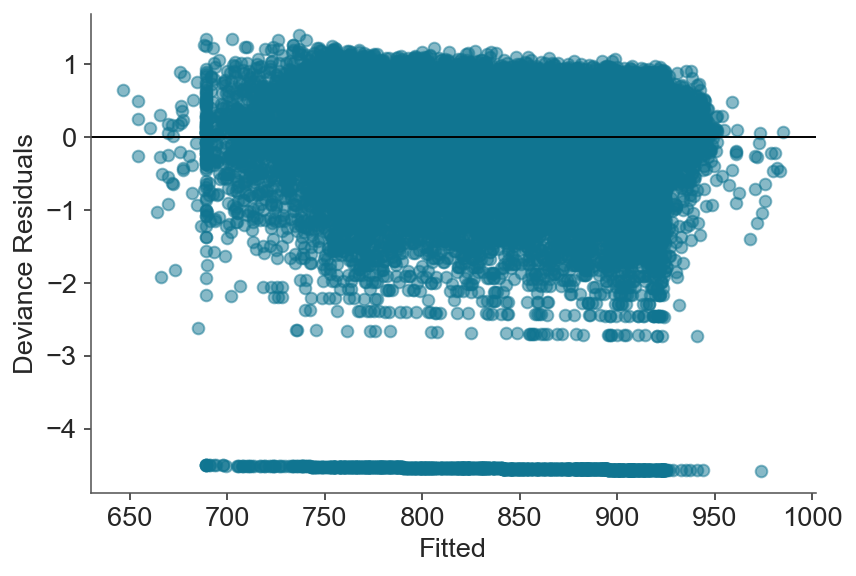

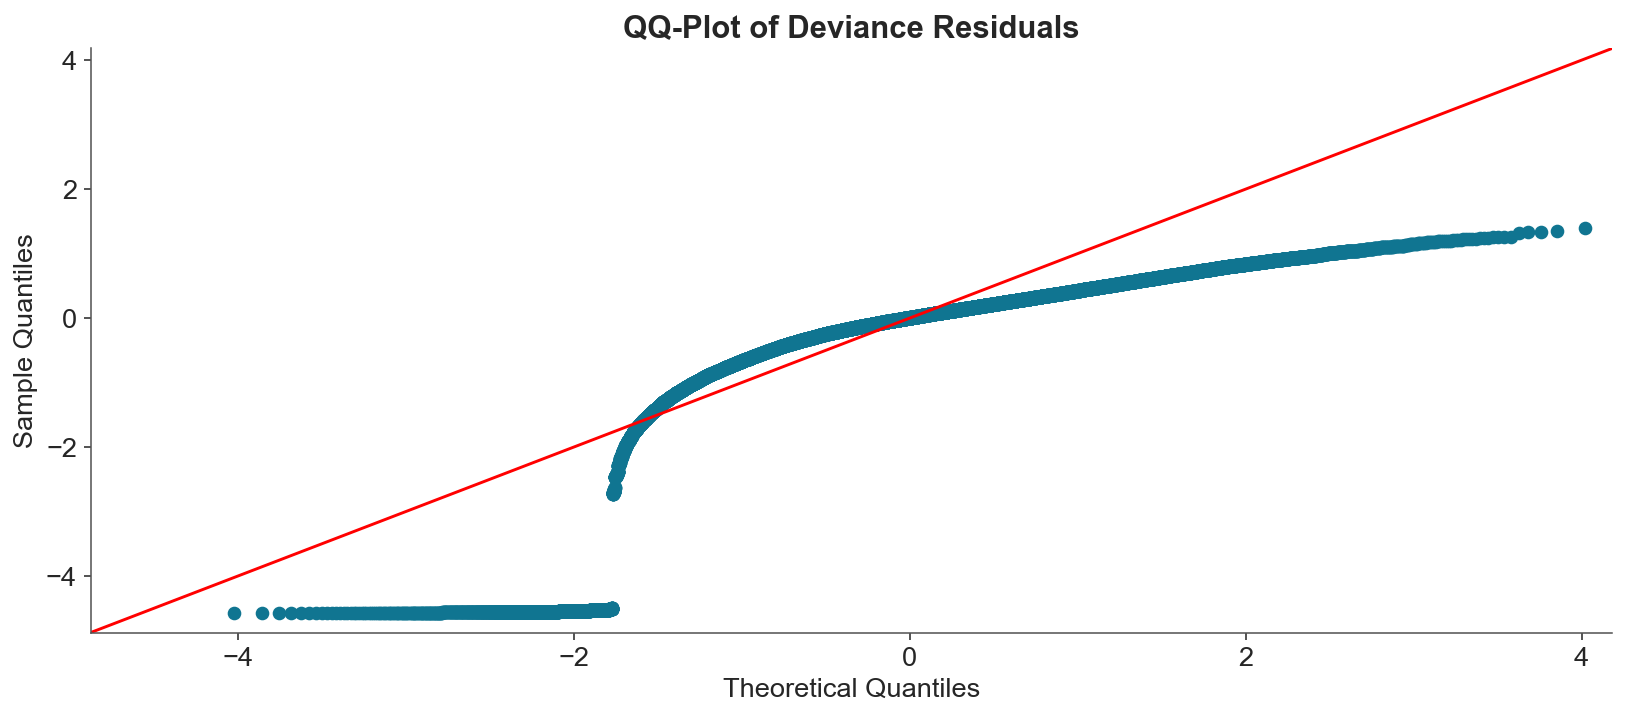

In [26]:
# -- 5. Baseline Gamma GLM --
formula_base = f"{y_col} ~ Error + Surprise"
model_base = smf.glm(formula_base, df, family=sm.families.Gamma(sm.families.links.log())).fit()
print(model_base.summary())

# Dispersion check
phi_hat = model_base.deviance / model_base.df_resid
print("Dispersion (φ̂):", phi_hat)

# Residual diagnostics
plt.figure(figsize=(6, 4))
plt.scatter(model_base.fittedvalues, model_base.resid_deviance, alpha=0.5)
plt.axhline(0, color='k', lw=1)
plt.xlabel("Fitted")
plt.ylabel("Deviance Residuals")
plt.show()

sm.qqplot(model_base.resid_deviance, line='45')
plt.title("QQ-Plot of Deviance Residuals")
plt.show()




In [27]:
# -- 6. Collinearity (VIF) --
X_vif = sm.add_constant(df[continuous_cols])
vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_df)



   variable       VIF
0     const  2.015018
1     Error  1.000002
2  Surprise  1.000002


In [28]:
# -- 7. Interaction Test --
formula_int = "rt ~ Error * Surprise"
model_int = smf.glm(formula_int, df, family=sm.families.Gamma(sm.families.links.log())).fit()
lr_stat = 2 * (model_int.llf - model_base.llf)
p_val = stats.chi2.sf(lr_stat, model_int.df_model - model_base.df_model)
print("Interaction LRT:", lr_stat, "p-value:", p_val)
print(model_int.summary())



Interaction LRT: 1.7851871937746182 p-value: 0.18151365681390152
                 Generalized Linear Model Regression Results                  
Dep. Variable:                     rt   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34556
Model Family:                   Gamma   Df Model:                            3
Link Function:                    log   Scale:                         0.25957
Method:                          IRLS   Log-Likelihood:            -2.9660e+05
Date:                Mon, 12 May 2025   Deviance:                       37750.
Time:                        12:42:19   Pearson chi2:                 8.97e+03
No. Iterations:                    11   Pseudo R-squ. (CS):            0.01962
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [29]:
# -- 8. Add Manipulation Flags --
formula_flags = "rt ~ Error + Surprise + Attention + Coh + Exp"
model_flags = smf.glm(formula_flags, df, family=sm.families.Gamma(sm.families.links.log())).fit()
print(model_flags.summary())

/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                     rt   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34554
Model Family:                   Gamma   Df Model:                            5
Link Function:                    log   Scale:                         0.25565
Method:                          IRLS   Log-Likelihood:            -2.9721e+05
Date:                Mon, 12 May 2025   Deviance:                       37633.
Time:                        12:42:19   Pearson chi2:                 8.83e+03
No. Iterations:                    13   Pseudo R-squ. (CS):            0.03284
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.9064      0.007   1039.171      0.0

In [30]:
# -- 9. Flags × Continuous Interactions --
cont = " + ".join(continuous_cols)
flags = " + ".join(flag_cols)
formula_flags_int = f"rt ~ ({cont}) * ({flags})"
model_flags_int = smf.glm(formula_flags_int, df, family=sm.families.Gamma(sm.families.links.log())).fit()
print(model_flags_int.summary())



/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                     rt   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34549
Model Family:                   Gamma   Df Model:                           10
Link Function:                    log   Scale:                         0.25621
Method:                          IRLS   Log-Likelihood:            -2.9699e+05
Date:                Mon, 12 May 2025   Deviance:                       37583.
Time:                        12:42:20   Pearson chi2:                 8.85e+03
No. Iterations:                    13   Pseudo R-squ. (CS):            0.03823
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              6.8694      0

In [36]:
model_flags_int.pseudo_rsquared()

0.038226383058818425

In [ ]:
df = pd.DataFrame(
    {
        "Error": response_error.flatten(),
        "Surprise": surprise.flatten(),
        "Attention": attention.flatten(),
        "Coh": coherence.flatten(),
        "Exp": expectation.flatten(),
        "rt": reaction_time.flatten(),
    }
)

y = df['rt'].values
n = len(df)

results = []

# -- Unconditional fits --
# Gamma (no predictors)
a, loc, scale = stats.gamma.fit(y, floc=0)
ll = stats.gamma.logpdf(y, a, loc, scale).sum()
k = 2
aic = 2*k - 2*ll
bic = k * np.log(n) - 2*ll
results.append({'Model': 'Gamma (no predictors)', 'Params': k, 'AIC': aic, 'BIC': bic, 'Pseudo_R2': np.nan})

# Log-Normal (no predictors)
s, loc, scale = stats.lognorm.fit(y, floc=0)
ll = stats.lognorm.logpdf(y, s, loc, scale).sum()
k = 2
aic = 2*k - 2*ll
bic = k * np.log(n) - 2*ll
results.append({'Model': 'Lognormal (no predictors)', 'Params': k, 'AIC': aic, 'BIC': bic, 'Pseudo_R2': np.nan})

# -- Conditional GLMs --
formulas = [
    # E-only
    "rt ~ Error",
    "rt ~ Error + Attention + Coh + Exp",
    "rt ~ Error + Attention + Coh + Exp + Error:Attention + Error:Coh + Error:Exp",
    "rt ~ Error * (Attention + Coh + Exp)",

    # S-only
    "rt ~ Surprise",
    "rt ~ Surprise + Attention + Coh + Exp",
    "rt ~ Surprise + Attention + Coh + Exp + Surprise:Attention + Surprise:Coh + Surprise:Exp",
    "rt ~ Surprise * (Attention + Coh + Exp)",

    # E + S
    "rt ~ Error + Surprise",
    "rt ~ Error + Surprise + Attention + Coh + Exp",
    "rt ~ Error + Surprise + Attention + Coh + Exp + Error:Attention + Error:Coh + Error:Exp",
    "rt ~ Error + Surprise + Attention + Coh + Exp + Surprise:Attention + Surprise:Coh + Surprise:Exp",
    "rt ~ (Error + Surprise) * (Attention + Coh + Exp)",
    "rt ~ Error * Surprise * (Attention + Coh + Exp)"
]

for f in formulas:
    model = smf.glm(f, df, family=sm.families.Gamma(sm.families.links.Log())).fit()
    params = int(model.df_model) + 1
    aic = model.aic
    bic = model.bic_llf
    pseudo = model.pseudo_rsquared()
    results.append({'Model': f, 'Params': params, 'AIC': aic, 'BIC': bic, 'Pseudo_R2': pseudo})

df_res = pd.DataFrame(results)
df_res

,Model,Params,AIC,BIC,Pseudo_R2
0,Gamma (no predictors),2,536382.164043,536399.064947,NaN
1,Lognormal (no predictors),2,583722.436232,583739.337136,NaN
2,rt ~ Error,2,593221.146333,593238.047238,0.019364
3,rt ~ Error + Attention + Coh + Exp,5,594445.937193,594488.189454,0.032591
4,rt ~ Error + Attention + Coh + Exp + Error:Att...,8,594025.286951,594092.890569,0.037862
5,rt ~ Error * (Attention + Coh + Exp),8,594025.286951,594092.890569,0.037862
6,rt ~ Surprise,2,596334.394928,596351.295832,0.000255
7,rt ~ Surprise + Attention + Coh + Exp,5,597550.315294,597592.567555,0.008669
8,rt ~ Surprise + Attention + Coh + Exp + Surpri...,7,597535.441368,597594.594533,0.008815
9,rt ~ Surprise * (Attention + Coh + Exp),7,597535.441368,597594.594533,0.008815


In [59]:
best_rt_model = smf.glm("rt ~ Error * (Attention + Coh + Exp)", df, family=sm.families.Gamma(sm.families.links.Log())).fit()
print(best_rt_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                     rt   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34552
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                         0.25620
Method:                          IRLS   Log-Likelihood:            -2.9700e+05
Date:                Mon, 12 May 2025   Deviance:                       37586.
Time:                        13:27:27   Pearson chi2:                 8.85e+03
No. Iterations:                    13   Pseudo R-squ. (CS):            0.03786
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           6.8696      0.009    8

## GLM ERR

In [77]:
df_err = pd.DataFrame(
    {
        "rt": reaction_time.flatten(),
        "Attention": attention.flatten(),
        "Coh": coherence.flatten(),
        "Exp": expectation.flatten(),
        "error": response_error.flatten(),
    }
)

# -- Conditional GLMs for the Error Model (Gamma, log-link) --
formulas = [
    "error ~ rt",
    "error ~ rt + Attention + Coh + Exp",
    "error ~ rt * (Attention + Coh + Exp)"
]

results = []
for f in formulas:
    m = smf.glm(f, df_err, family=sm.families.Gamma(sm.families.links.Log())).fit()
    results.append({
        'Model':       f,
        'Params':      int(m.df_model) + 1,
        'AIC':         m.aic,
        'BIC':         m.bic_llf,
        'Pseudo_R2':   m.pseudo_rsquared(),
    })
df_res = pd.DataFrame(results)
df_res


,Model,Params,AIC,BIC,Pseudo_R2
0,error ~ rt,2,-29206.268520,-29189.367615,0.016225
1,error ~ rt + Attention + Coh + Exp,5,-30435.376911,-30393.124650,0.041746
2,error ~ rt * (Attention + Coh + Exp),8,-30756.657253,-30689.053635,0.047462


In [ ]:
best_err_model = smf.glm("error ~ rt * (Attention + Coh + Exp)", df_err, family=sm.families.Gamma(sm.families.links.Log())).fit()
print(best_err_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  error   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34552
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                          1.0467
Method:                          IRLS   Log-Likelihood:                 15386.
Date:                Mon, 12 May 2025   Deviance:                       49137.
Time:                        13:48:44   Pearson chi2:                 3.62e+04
No. Iterations:                    24   Pseudo R-squ. (CS):            0.04746
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.1271      0.026    -43.407   